In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.draw import polygon
from skimage import io, filters, measure, segmentation, color, data
from scipy import ndimage

from scipy.ndimage import label
from scipy.ndimage.morphology import binary_closing
import matplotlib.pylab as plt
from skimage.filters import threshold_multiotsu, threshold_otsu
from matplotlib.path import Path
import shutil
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *


<ipython-input-1-75ceae9cb753>:9: DeprecationWarning: Please use `binary_closing` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  from scipy.ndimage.morphology import binary_closing


#   Patch detection

In [ ]:
def class_contrast(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    means = [np.mean(image[regions == i]) for i in range(len(thresholds) + 1)]
    contrast = np.std(means)  # Dispersion des moyennes
    return contrast

def otsu_criterion(image, thresholds):
    """
    Calcule la variance intra-classe totale après seuillage multi-Otsu.
    Plus cette valeur est faible, meilleure est la séparation des classes.
    """
    regions = np.digitize(image, bins=thresholds)
    total_variance = 0
    
    for i in range(len(thresholds) + 1):
        mask = regions == i
        if np.any(mask):
            variance = np.var(image[mask])
            total_variance += variance
    
    return total_variance


from matplotlib.path import Path
def otsu_detection(nbclasse, image, m_size, sigma_X, sigma_Y, mode_switch, min_nbclass = 2):
    max_interclasse = 0
    min_intraclasse = 1e12
    max_nbclasse = 0
    blurred_image = cv2.GaussianBlur(image, (m_size, m_size), sigmaX = sigma_X, sigmaY = sigma_Y)
    
    #Find the best number of classes
    for n in range(min_nbclass,nbclasse + 1):
        thresholds = threshold_multiotsu(blurred_image[image!=0], classes = n)
        if mode_switch == 0:
            contrast = class_contrast(image, thresholds)
            if contrast > max_interclasse:
                max_interclasse = contrast
                max_nbclasse = n
                
        elif mode_switch == 1:
            intra_std = otsu_criterion(image, thresholds)
            if intra_std < min_intraclasse:
                min_intraclasse = intra_std
                max_nbclasse = n
        else:
            raise ValueError("otsu_detection mode_switch must be 0 or 1")
    # max_nbclasse = 5
    return cluster_detection(blurred_image, max_nbclasse)

def contours_to_label_fct(labeled_image, contours, num_features):
    L1 = labeled_image.shape[0]
    L2 = labeled_image.shape[1]
    ##########External contour##########
    contour_to_label = []
    for j, contour in enumerate(contours):  
        external_path = Path(contour)
        for k in range(1,num_features + 1):
            patch = np.argwhere(labeled_image == k)
            inside = external_path.contains_points(patch)
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label.append([j, k])
                break
        else: 
            contour_to_label.append([j, -1]) #Si aucun élément n'est contenu dans le contour, c'est un contour interieur    

    ##########Internal contour##########
    contour_to_label = np.array(contour_to_label)
    mask = contour_to_label[:,1] == -1

    for _, int_id_contour in enumerate(contour_to_label[mask][:,0]):
        for _, (id_contour, idpatch) in enumerate(contour_to_label[~mask]):
            external_path = Path(contours[id_contour])
            inside = external_path.contains_points(contours[int_id_contour])
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label[int_id_contour,1] = idpatch 
                break
        else:
            for point in contours[int_id_contour]:
                y, x = np.floor(point).astype(int)

                neighbors = [(y+1, x), (y-1, x), (y, x+1), (y, x-1)]
                for y_neighbor, x_neighbor in neighbors: 
                    if 0 <= x_neighbor < L1 and 0 <= y_neighbor < L2:
                        label_val = labeled_image[y_neighbor, x_neighbor]
                        if label_val:
                            contour_to_label[int_id_contour, 1] = label_val
                            break

                    
        if contour_to_label[int_id_contour,1] == -1:
            print("A contour is not linked to a cluster, id_contour = {}".format(int_id_contour))

    
    #Change the contour_id to the patch_id since it will be the same in all_contours_to_label and all_contours 
    return contour_to_label


def cluster_detection(blurred_image, nbclass):
    feature_areas = []
    all_contours = []
    all_labeled_image = []
    
    thresholds = threshold_multiotsu(blurred_image[blurred_image!=0], classes = nbclass)#Find the thresholds
    regions = np.digitize(blurred_image, bins=thresholds)
    all_contours_to_label = []
    
    for i in range (0, nbclass):
        mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
        masked_image = np.where(mask, 1, -1)

        smoothed_image = filters.gaussian(masked_image, sigma=1) #Allow to fill the possible holes in the clusters
        
        original = smoothed_image
        thres = threshold_otsu(smoothed_image) #Find a threshold between background and the class
        binary = original > thres

        binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
        labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
        feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions (ravel aplati le tableau)
        all_labeled_image.append(labeled_image)

        contours = measure.find_contours(binary_closed, level=0.5)
        all_contours.extend(contours)
    
        ##########Link contours to labeled clusters##########

        contours_to_label = contours_to_label_fct(labeled_image, contours, num_features)
        contours_to_label[:,0] = i
        all_contours_to_label.extend(contours_to_label)  
        
        
        
    return np.array(feature_areas), np.array(all_contours), np.array(all_labeled_image), thresholds, np.array(all_contours_to_label)


def second_detection(image, all_contours, all_labeled_image, all_contours_to_label):
    print("*************SECOND DETECTION")
    
    
    new_contours = np.copy(all_contours)
    new_labeled_image  = np.copy(all_labeled_image)
    new_contours_to_label = np.copy(all_contours_to_label)
    new_featured_areas = []
    new_thresholds = []
    contour_contained = []
    
    switch = 0
    for j, labeled_image in enumerate(all_labeled_image):
        for i in range(1, np.max(labeled_image)+1):
            mask = labeled_image == i
            if np.sum(mask) > 7000:
                
                f_image = np.zeros_like(image)
                f_image[mask] = image[mask]
                if (np.std(f_image[mask]) >= 20):
                    
                    blurred_sys2 = cv2.medianBlur(f_image, 7)
                    # blurred_sys2[~mask] = 0

                    try :
                        feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = otsu_detection(5, blurred_sys2, 1,0,0, 1, min_nbclass = 5)
                    except ValueError:
                        feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = otsu_detection(4, blurred_sys2, 1,0,0, 1, min_nbclass = 4)

                    id_contour = np.argwhere(np.all(all_contours_to_label == [j, i], axis = 1)) #Find the biggest external contour
                    contours = all_contours[id_contour[0,0]]
                    contour_contained.append(id_contour[0,0])
                    
                    
                    external_path = Path(contours)
                    for k, contour in enumerate(all_contours):  #Find all inside contour to delete them
                        if k == id_contour[0,0]: 
                            continue
                        inside = external_path.contains_points(contour)
                        if (np.sum(inside)/len(inside) > 0.5): #Au moins un élément dans être contenu dans le contour
                            contour_contained.append(k)
                    if(len(contour_contained) == 0): 
                        print("Error, no contour contained") #Si aucun élément n'est contenu dans le contour, c'est un contour interieur
                        print(contour_contained)

                    ######Find the index linked to the empty space######
                    id_emptysys = np.argwhere(np.all(contour_to_label2[:] == [0,1], axis = 1))[:,0] 
                    
                    if np.any(np.all(contour_to_label2[:] == [0,2], axis = 1)): 
                        id_emptysys_bis = np.argwhere(np.all(contour_to_label2[:] == [0,2], axis = 1))[0,0]
                        id_emptysys = np.append(id_emptysys, id_emptysys_bis)
                   
                    mask2 = all_labeled_image2[0] == 1  
                    all_labeled_image2[0][mask2] = 0 #Remove the empty space considered as a patch
                    mask3 = np.ones(len(contour_to_label2), dtype = bool)
                    mask3[id_emptysys] = False
                    #To avoid taking into account small patches created at the boundary, I apply a threshold on the size for the new detection
                    for l, label in enumerate(all_labeled_image2):
                        for k in range(1, np.max(label)):
                            if np.sum(label == k) < 500:
                                id = np.argwhere(np.all(contour_to_label2[:] == [l,k], axis = 1))[:,0]
                                mask4 = all_labeled_image2[l] == k
                                all_labeled_image2[l][mask4] = 0
                                mask3[id] = False
                    
                    new_contours = np.append(new_contours, all_contours2[mask3], axis = 0) #Add the new ones to the list
                    contour_to_label2[:,0] += len(new_labeled_image)
                    new_contours_to_label = np.append(new_contours_to_label, contour_to_label2[mask3], axis = 0)
                    new_labeled_image = np.append(new_labeled_image, all_labeled_image2, axis = 0)
                    new_thresholds.append(thresholds2)
                    
    new_contours = np.delete(new_contours, contour_contained, axis = 0) #delete the old contours
    f_contours_to_label = new_contours_to_label[contour_contained]  #delete replaced patches
    for id_label, id_patch in f_contours_to_label:
        mask2 = new_labeled_image[id_label] == id_patch
        new_labeled_image[id_label][mask2] = 0
    new_contours_to_label = np.delete(new_contours_to_label, contour_contained, axis = 0) #delete the old contours -> patches link
    
    for i, label in enumerate(new_labeled_image):
        for j in range(1, np.max(label)):
            count = np.sum(label == j)
            new_featured_areas.append(count)
        
    return np.array(new_featured_areas), new_contours, new_labeled_image, np.array(new_thresholds), new_contours_to_label
                

def process_detection(folderpath, nbclasse, nbsnap, nu, switch = 0, m_size = 3, sigma_X = 0, sigma_Y = 0, mode_switch = 0, snd_detection_switch = 0):
    L1 = read_parameters(folderpath)[0]
    L2 = read_parameters(folderpath)[1]
    nu = read_parameters(folderpath)[2]

    lin_bins = np.arange(0, L1 * L2)
    histo = np.zeros(len(lin_bins) - 1)
    avg_width = 0

    
    
    elements = os.listdir("{}Snapshots/".format(folderpath))
    for element in elements[:nbsnap]:
        feature_areas2 = []
        all_contours2 = []
        all_labeled_image2 = []
        
        data = np.loadtxt("{}Snapshots/{}".format(folderpath,element), comments='#')
        sys = data.reshape(L1, L2).T
        sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV
        # image = cv2.GaussianBlur(sys_image_bis, (m_size, m_size), sigmaX = sigma_X, sigmaY = sigma_Y)
        
        
        feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclasse, sys_image_bis, m_size, sigma_X, sigma_Y, mode_switch)
            
        if len(all_contours) > 600 and nu < 0.5:
            image = cv2.medianBlur(sys_image_bis, 5)            
            feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclasse, image, 7,0,0, mode_switch)
        elif (snd_detection_switch):
            feature_areas2, all_contours2, all_labeled_image2, thresholds2, contour_to_label2 = second_detection(sys_image_bis, all_contours, all_labeled_image, contour_to_label)

        if switch: 
            fig, ax = plt.subplots(figsize = (10,10))
            ax.imshow(sys_image_bis, cmap='binary')
            if(len(all_contours2) > 0):
                for contour in all_contours2:
                    ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5) 
            else:
                for contour in all_contours:
                    ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)       
            ax.axis('off')
            plt.savefig("Snapshots/{}/{}.png".format(nu, element[:-4]))
            plt.close(fig)

        if (snd_detection_switch & len(feature_areas2)>0):
            histo += np.histogram(feature_areas2, bins=lin_bins)[0]
        else:
            histo += np.histogram(feature_areas, bins=lin_bins)[0]
        
        # if(len(all_contours2) > 0):
        #     result_analysis = patch_analysis(all_labeled_image2, L2, sys_image_bis, all_contours2)
        # else:
        #     result_analysis = patch_analysis(all_labeled_image, L2, sys_image_bis, all_contours)
        # centers = result_analysis[0]
        # avg_width += result_analysis[1]
        
    avg_width = avg_width / nbsnap
    return histo, avg_width


def size_distribution(Thisto, Tnu, L1, L2, nbins = 15, xmin = 1e2, xmax = 1e4):
    NCURVES = len(Tnu)
    colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
    fig, ax1 = plt.subplots(figsize=(10, 10))
        
    ax2 = fig.add_axes([0.3, 0.25, 0.28, 0.28])
    for j, (histo, x) in enumerate(zip(Thisto[:], Tnu[:])):

        log_bins = np.logspace(np.log10(1), np.log10(L1 * L2), nbins+1)
        log_histo = np.zeros(nbins)

        norm_histo = histo / np.sum(histo)

        for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
            # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
            overlap = (lin_bins[:-1] >= log_bins[i]) & (lin_bins[:-1] < log_bins[i + 1])
            # Ajouter les comptages de ces bins linéaires au bin logarithmique
            if len(norm_histo[overlap])!=0:
                log_histo[i] = np.sum(norm_histo[overlap])/len(norm_histo[overlap])
                # log_histo[i] = np.sum(data[overlap])


        bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
        area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
        log_histo_normalized = log_histo / area  # Normalisation


        mask = log_histo_normalized!= 0
        filt_hist = log_histo_normalized[mask]
        filt_bins = log_bins[:-1][mask]

        result, xs, _ , perr = fit_powerlaw(filt_bins, filt_hist, start_x = xmin, stop_x = xmax, switch = 1,   plot=True, f_scale=1.0,
                                            function_to_fit='power')


        ax1.plot(log_bins[:-1],log_histo_normalized, lw = 5, color = colors[j])
        
        ax1.plot(xs, powerlaw(xs, *result.x), 'k--', lw = 3, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                                np.round(perr[1], 2)))
        ax2.scatter(x, -np.round(result.x[1], 3), s = 200, color = colors[j])
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])

    ax1.axvline(L1 * L2, ls = '--', lw = 3, c = 'k')
    para_fig(ax1, "s", "P(s)", "loglog", tickssize = 45, labelsize = 45)
    para_fig(ax2, r"$\nu$", r"$\tau _p$", "lin", tickssize = 35, labelsize = 35)
    ax2.set_ylim(1.42, 1.65)
    ax2.xaxis.set_label_coords(0.5, -0.2) 
    ax2.yaxis.set_label_coords(-0.36, 0.5) 
    ax2.set_xticks([0.2,0.6])
    ax2.set_yticks([1.5,1.6])
    
    # plt.tight_layout()
    # ax.legend(fontsize = 20)
    plt.show()
    
    
def patch_analysis(all_labeled_image, L2, sys_image, contours, nbline_avg = 10): #Find epicenter and width of patches   

    all_centers = []
    counter = 0
    avg_width = 0
    # fig, ax = plt.subplots(figsize = (10,10))
    # ax.imshow(sys_image, cmap='binary')
    for j in range(len(all_labeled_image)):
        for i in range(0, np.max(all_labeled_image[j]) + 1):
            indices = np.argwhere(all_labeled_image[j] == i) #Tableau de coordonnées (n, 2)
            y_cm, x_cm = indices.mean(axis=0)   
            # ax.scatter(x_cm, y_cm, color='green', s=20)
            
            if np.sum(indices[:, 0] == (L2//2)) != 0:
                # width_point = indices[indices[:, 0] == (L2//2)]
                # y_width = width_point[:, 0] 
                # x_width = width_point[:, 1]
                # ax.scatter(x_width, y_width, color='green', s=20)
                    
                s_counter = 0
                space_avg = 0
                for n in range((L2//2 - nbline_avg), (L2//2 + nbline_avg + 1)): #average the width of the patch on 21 lines
                    if np.sum(indices[:, 0] == n) != 0:
                        space_avg += np.sum(indices[:, 0] == n)
                        s_counter += 1
                # avg_width += np.sum(indices[:, 0] == (L2//2))
                avg_width += space_avg/s_counter
                counter += 1
                
                
    if counter == 0 : 
        fig, ax = plt.subplots(figsize = (10,10))
        ax.imshow(sys_image, cmap='rainbow')
        for contour in contours:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)
        ax.axis('off')
        plt.savefig("Error.pdf")
    else:
        avg_width /= counter
            
    all_centers.extend([x_cm, y_cm])
    
    # for contour in contours:
    #     ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=0.5)
    # plt.savefig("snapwidth.pdf")
    
    return all_centers, avg_width

    

In [7]:
folderpaths = ["/data1/DATA_Duplat/Brut/Patch_detection/Pa1n{}/".format(nb) for nb in range(1, 7)]
# folderpaths = ["/data1/DATA_Duplat/Brut/Patch_detection/Pa1n2/"]
# nbclasse = 6
nbsnap = 20
Tnu = [read_parameters(folderpath)[2] for folderpath in folderpaths]
switch = 1 # Switch to save snapshots or not
Tcriterion = [1, 1, 1, 0, 1, 0] # 1: Interclass, 0: Intraclass
Tnbclass =   [5, 5, 5, 5, 5, 4]
Tmsize =     [3, 3, 3, 3, 5, 3]
Tsigma_X =   [0, 0, 0, 0, 3, 2]
Tsigma_Y = Tsigma_X


if switch :
    if os.path.exists("Snapshots"):
        shutil.rmtree("Snapshots")

    # Recréer un dossier vide
    os.makedirs("Snapshots")


    for nu in Tnu:
        os.makedirs("Snapshots/{}".format(nu), exist_ok=False)

results = np.array(Parallel(n_jobs=-1)(delayed(process_detection)(folderpath, nbclass, nbsnap, nu, switch, msize, sigma_X, sigma_Y, mode_switch, snd_detection_switch)
                                  for (folderpath, nu, msize, sigma_X, sigma_Y, nbclass, mode_switch) in zip(folderpaths, Tnu, Tmsize, Tsigma_X, Tsigma_Y, Tnbclass, Tcriterion)))

KeyboardInterrupt: 

In [ ]:
Thisto, avg_width= results.T

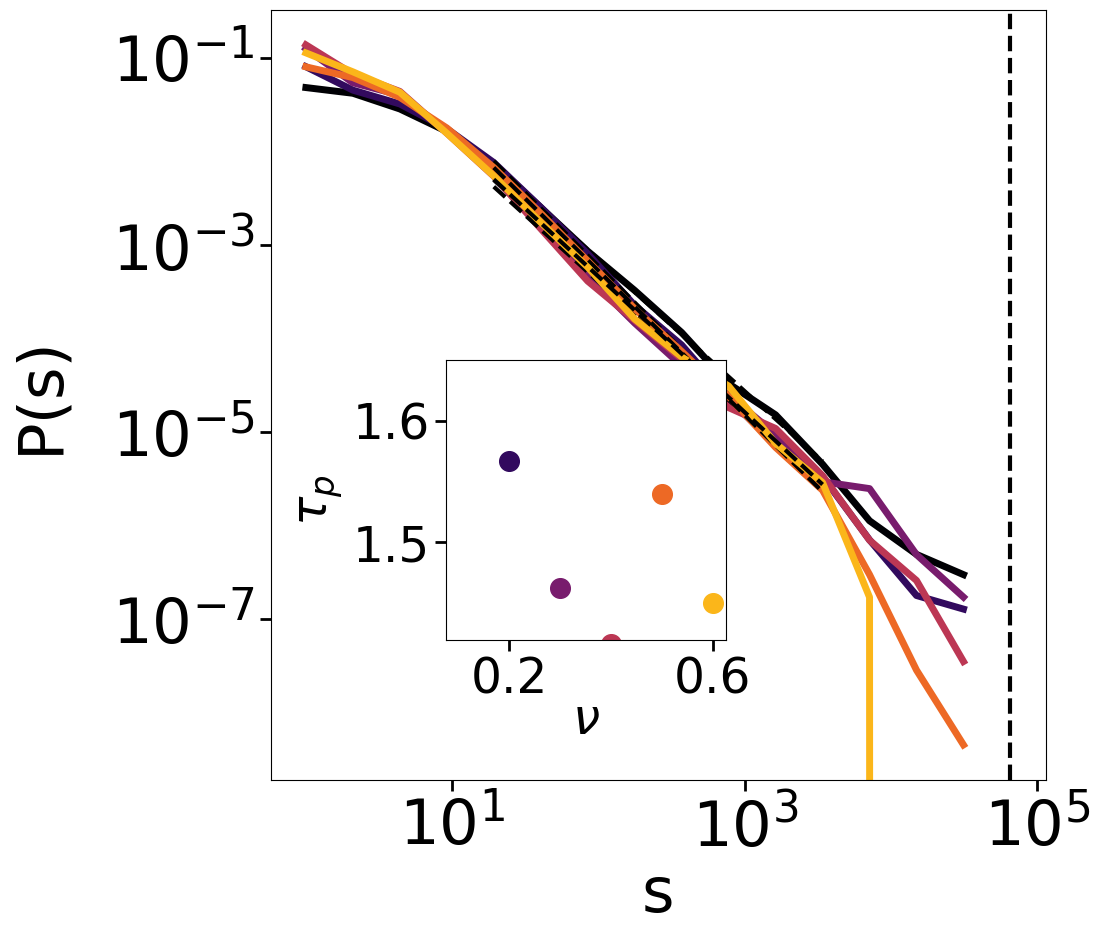

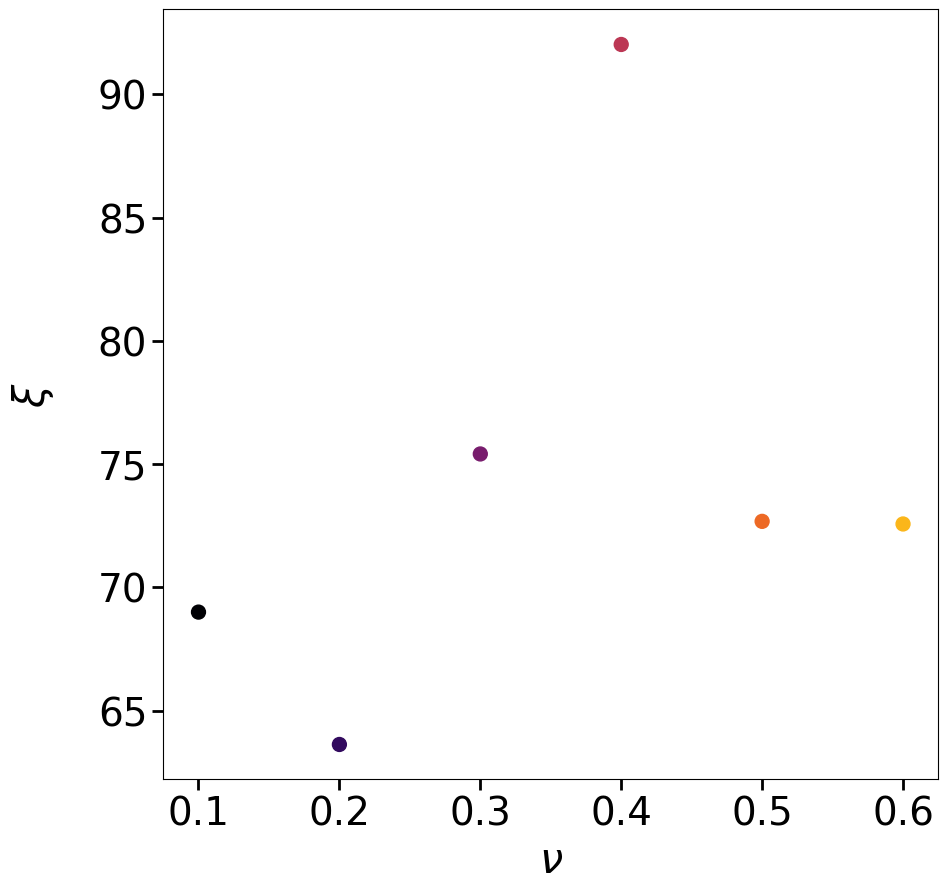

In [9]:
plt.style.use('default')
plt.rcParams['font.weight'] = 'normal' 

L1 = read_parameters(folderpaths[0])[0]
L2 = read_parameters(folderpaths[0])[1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

lin_bins = np.arange(0, L1 * L2)
size_distribution(Thisto, Tnu, L1, L2, nbins = 15, xmin = 10, xmax = 5000)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(Tnu, avg_width/2, c=colors, s = 100)

para_fig(ax, r'$\nu$', r'$\xi$')
plt.show()

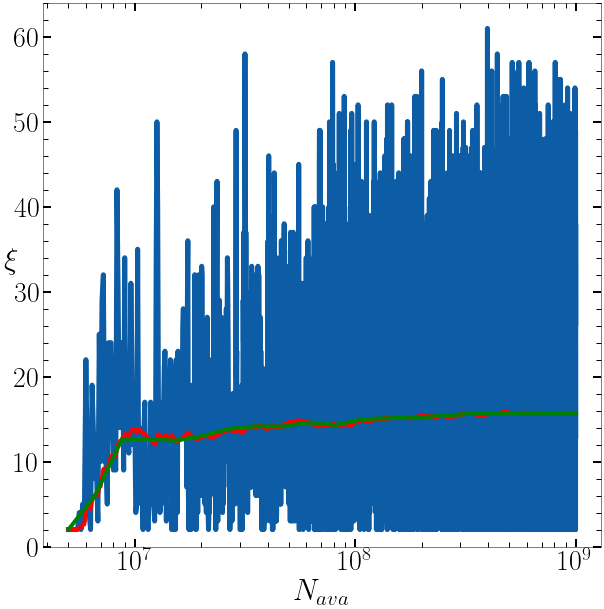

<Figure size 504x504 with 0 Axes>

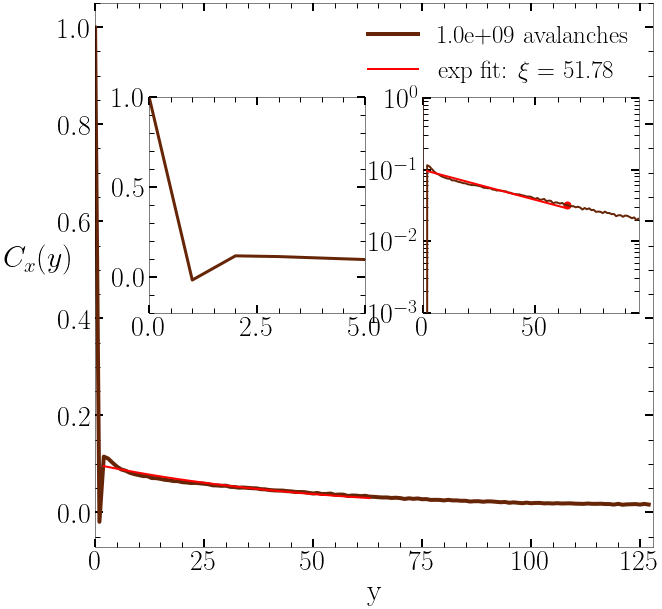

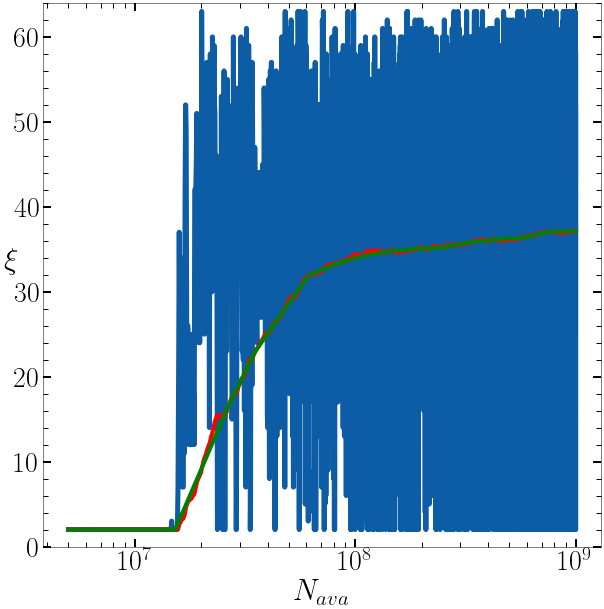

<Figure size 504x504 with 0 Axes>

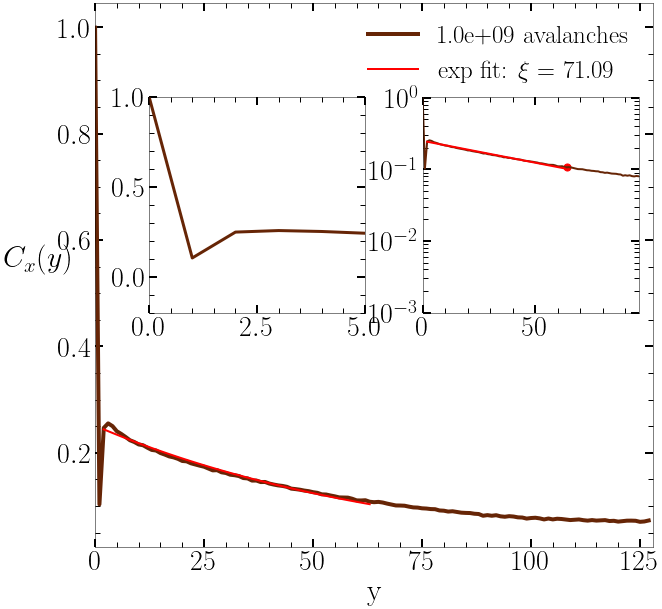

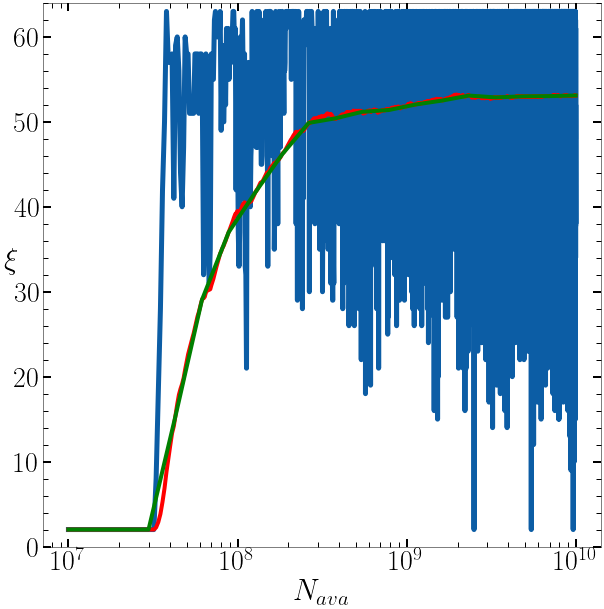

<Figure size 504x504 with 0 Axes>

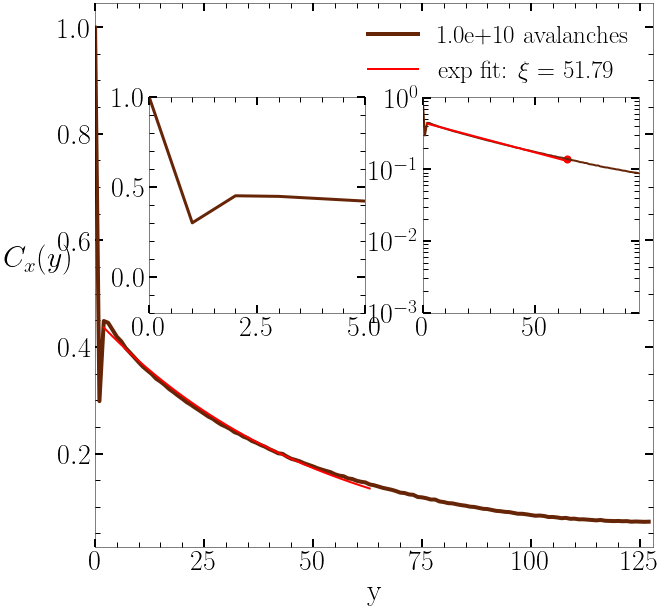

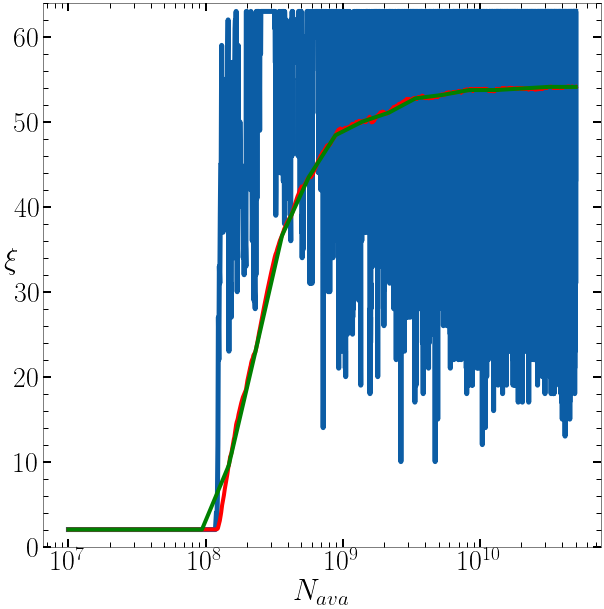

/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


<Figure size 504x504 with 0 Axes>

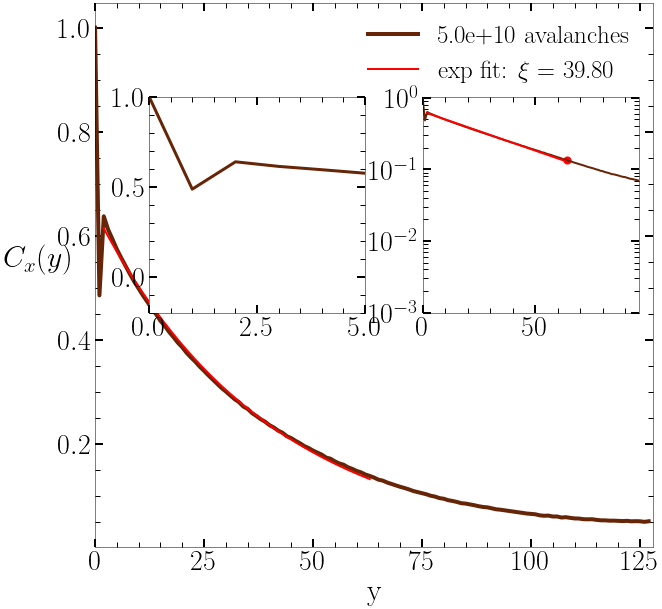

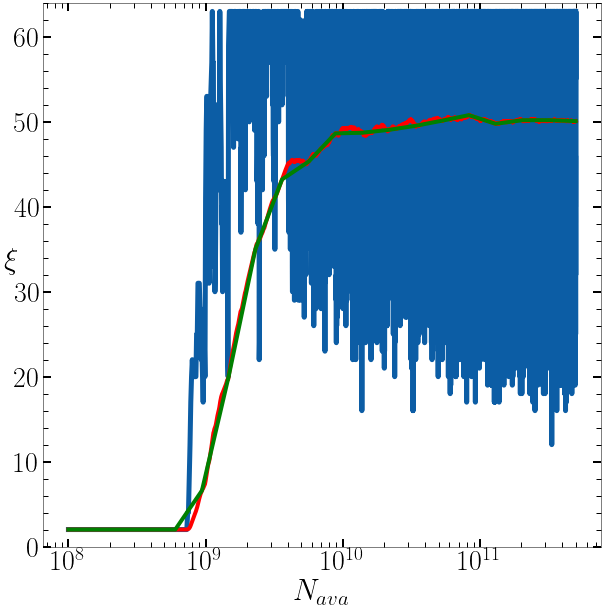

<Figure size 504x504 with 0 Axes>

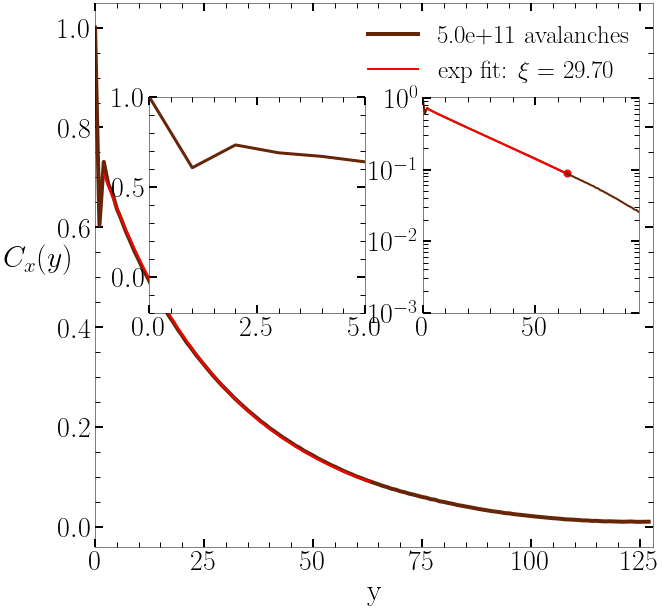

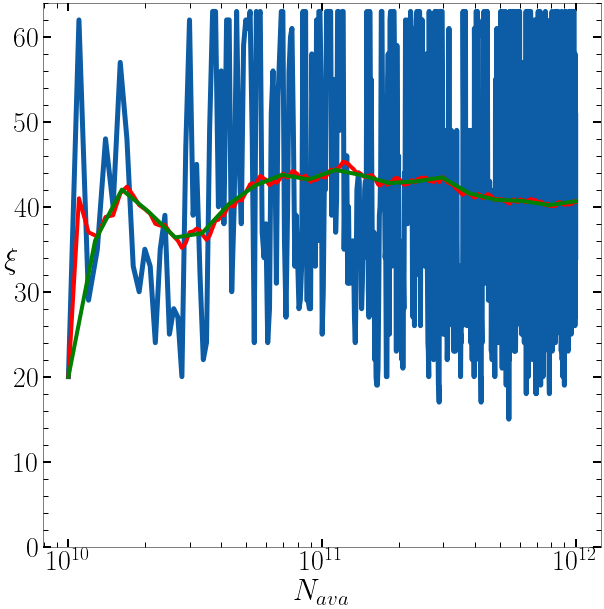

<Figure size 504x504 with 0 Axes>

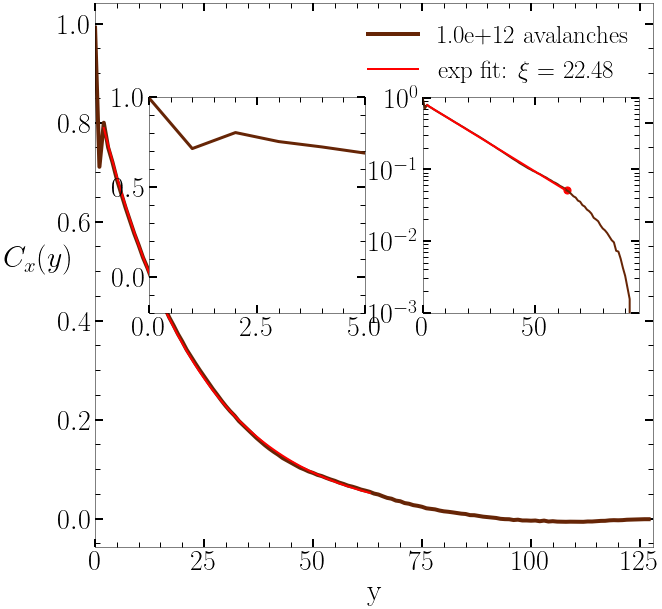

In [13]:
folderpaths = ["/data1/DATA_Duplat/Brut/PDF/PD1n{}/".format(nb) for nb in range(9, 15)]

Tiniava = [read_parameters(folder)[15][0] for folder in folderpaths]
Tdeltaava = [read_parameters(folder)[15][1] for folder in folderpaths]
Tnbava = [999900000, 999900000, 9999000000, 49999000000, 499900000000, 998000000000]

xi = []

for i, (folder, iniava, deltaava, nbava) in enumerate(zip(folderpaths, Tiniava, Tdeltaava, Tnbava)):
    clen, avg = corrlength(folder, iniava, deltaava, nbava, L2, numcol = 3,  switch_plot = 1)
    startmean = nbava - (nbava - iniava)*0.1
    meanXi = meancorrfct(folder,  deltaava, iniava, L1, L2, nbava, clen, startmean, tcorrel = [-1], numcol = 3, xmin_fit = 2, switch_plot = 1)
    xi.append(meanXi)

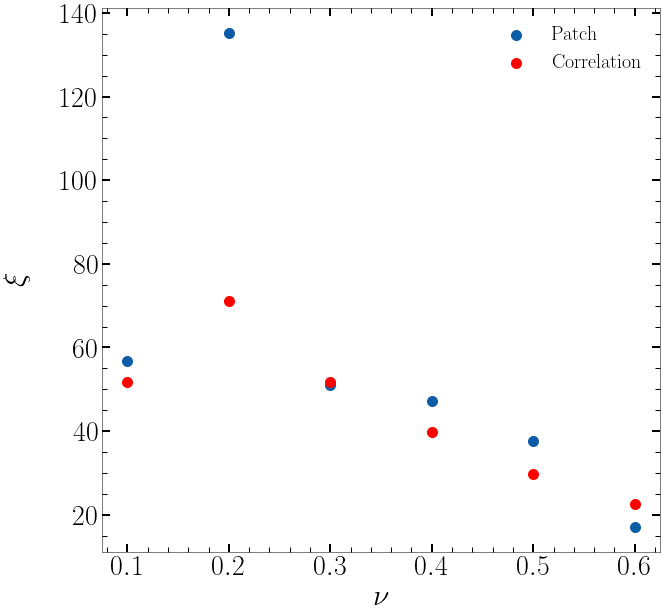

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tnu, avg_width, s = 100, c = 'C0', label = 'Patch')
ax.scatter(Tnu, xi, s = 100, c = 'red', label = 'Correlation')
para_fig(ax, r'$\nu$', r'$\xi$')
ax.legend(fontsize = 20)
plt.show()